In [1]:
from pathlib import Path #Accessing files
import sys #error management 
import scipy.integrate
import scipy.signal
import random
import math


%config InlineBackend.figure_format='retina'
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import pandas as pd

import matplotlib as mpl
import matplotlib.font_manager as fm

from lmfit.models import LinearModel, QuadraticModel, PseudoVoigtModel





#import spectrochempy as scp
#from spectrochempy.core.dataset.nddataset import NDDataset

mpl.rc('text', usetex=False)
#Code for using superscripts
def get_super(x):
    normal = "ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz0123456789+-=()"
    super_s = "ᴬᴮᶜᴰᴱᶠᴳᴴᴵᴶᴷᴸᴹᴺᴼᴾQᴿˢᵀᵁⱽᵂˣʸᶻᵃᵇᶜᵈᵉᶠᵍʰᶦʲᵏˡᵐⁿᵒᵖ۹ʳˢᵗᵘᵛʷˣʸᶻ⁰¹²³⁴⁵⁶⁷⁸⁹⁺⁻⁼⁽⁾"
    res = x.maketrans(''.join(normal), ''.join(super_s))
    return x.translate(res)
def get_sub(x):
    normal = "ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz0123456789+-=()"
    sub_s = "ₐ₈CDₑբGₕᵢⱼₖₗₘₙₒₚQᵣₛₜᵤᵥwₓᵧZₐ♭꜀ᑯₑբ₉ₕᵢⱼₖₗₘₙₒₚ૧ᵣₛₜᵤᵥwₓᵧ₂₀₁₂₃₄₅₆₇₈₉₊₋₌₍₎"
    res = x.maketrans(''.join(normal), ''.join(sub_s))
    return x.translate(res)
#Checks to make sure you are in the right folder, if this is wrong reload
import os
print(os.getcwd())

plt.rcParams['font.family'] = 'sans-serif'
def step_approx(t,it,per):
    T = per
    i = 1
    sum = 0.
    while i <= it: # compute the Fourier series for N iterations
        a = (1 / (2.*i-1.)) * -math.sin((2. * (2.*i-1.) * math.pi * t) / T)
        sum = sum + a
        i += 1
    return (2. / math.pi) * sum
def sine(x,dx,f,A):
    y = A*np.sin((x-dx)/f)
    return y
def get_time_p(slice_point,df_time_source): #Unfortunately complicated code needed to get the loc value for a certain index
    f_slice_time = df_time_source.columns[slice_point] #Converts index to actual time
    f_adj_col = np.array([abs(float(x-(f_slice_time))) for x in df_time_source.columns.to_numpy()])
    time_point = df_time_source.iloc[:, f_adj_col.argsort()[:1]].columns
    
    return time_point
def get_time_t(slice_time,df_time_source): #Unfortunately complicated code needed to get the loc value for a certain index
    f_adj_col = np.array([abs(float(x-(f_slice_time))) for x in df_time_source.columns.to_numpy()])
    time_point = df_time_source.iloc[:, f_adj_col.argsort()[:1]].columns
    
    return time_point
#These are the default limits of the peak fitting      
center_var = 10
sigma_var = 5
#Edit these parameters determine how constrained/open the fitting algorithim is 
def add_fancy_peak(prefix, center, amplitude, fwhm, fraction):
    peak = PseudoVoigtModel(prefix=prefix)
    pars = peak.make_params()
    pars[prefix + 'fraction'].set(0, vary=False)
    pars[prefix + 'amplitude'].set(amplitude, min = -1,max=1)
    if prefix == "p1_" or prefix == "p2_" or prefix == "p3_" : # Add specific Peaks here to ajust the parameters for them
        #This can be used to fix a certain peak while allowing others to vary and giving specific limits to a peak
        #To adjust independent peaks replace center_var/sigma_var with your preferred value in the pars statement
        pars[prefix + 'center'].set(center,min=center-center_var,max =center+center_var, vary= True)
        pars[prefix + 'sigma'].set(fwhm/2,min=fwhm/2-sigma_var,max =fwhm/2+sigma_var, vary = True)
    elif prefix == "p[# of peak here]_":
        pars[prefix + 'center'].set(center,min=center-center_var,max =center+center_var, vary= True)
        pars[prefix + 'sigma'].set(fwhm/2,min=fwhm/2-sigma_var,max =fwhm/2+sigma_var, vary = True)
    else:
        pars[prefix + 'sigma'].set(fwhm/2,min=fwhm/2-sigma_var,max =fwhm/2+sigma_var,vary =True)
        pars[prefix + 'center'].set(center,min=center-center_var,max =center+center_var, vary=True)
    return peak, pars

cmap = mpl.colormaps['plasma']


C:\Users\jdnor\Documents\GitHub\SwearerCode


In [3]:
#Loading Data
#This is where you load your data, it needs to be in a csv form with data spacing divisible by your period.
#This can be done using the spa_to_csv_binning.py code, or by just prepping your data appropriately in a csv
file_name = 'FTIR_250708_CuSiO2_Acetlylene_rt_500ppm_585_50nm_45mW_pMEIRS5s_split' # Name of your CSV without the filetype
file = pd.read_csv(file_name + ".csv",header = 0,index_col=0, dtype=np.float64)

df_spec_2D = pd.DataFrame(file)
fit_tracker={}
data_tracker = {}
df_spec_2D.columns = df_spec_2D.columns.map(float)
df_spec_2D.head
df_meanspec_1D = df_spec_2D.mean(axis = 1) # Take an average of the whole data set for a single spectra
df_averaged2D = df_spec_2D.sub(df_meanspec_1D, axis=0)#Mean is only one way to adjust the spectra, this makes it so that the deviation from the average is shown and small differences can be seen


In [5]:
#The psd processing
print(file_name) #Make sure you are processing the data you think you are
period = 200 #Length of your full on off period in seconds get this right!
spacing = (df_spec_2D.columns[1]-df_spec_2D.columns[0]) #Gets data interval, used to generate and shift modulation function
print(spacing)
dp_per_period = round(period/spacing)
trim_num = len(df_spec_2D.columns)%dp_per_period #Figures out the excess datapoints to create a set that is exactly some number 

df_psd2D = df_averaged2D.drop(columns =df_averaged2D.columns.to_list()[-trim_num:] ) # The trimmed dataset
phase_points = dp_per_period #Resolution of your phase data, matches the number of datapoints in your source
phase_list =[]
#Creates modulation set of a step function with the appropriate period and length. This is where to change if you want to use different modualtions
for t_pos, t in enumerate(df_psd2D.columns.to_list()):
        sin_point = step_approx(t,1000,period)
        sin_slice = np.full((df_psd2D.shape[0],1),fill_value=sin_point)
        if t_pos == 0:
            sin_set = sin_slice
           
        else:
           
            sin_set = np.concatenate((sin_set,sin_slice),axis =1)

shifted_sin_set = sin_set

for y_phase in range(phase_points):
    
    sin_shift = ((y_phase)*spacing+spacing/2) #This shifts depending on how many datapoints you have processed 
    for x in range(len(df_psd2D.columns)):
        
        shifted_sin_set[:,x] = step_approx((x-y_phase)*spacing,1000,period) #sin_set[:,x-y_phase+40]
            
    phase_slice = ((2)/df_psd2D.columns[-1])*np.trapz(y=np.multiply(df_psd2D,shifted_sin_set),x=df_psd2D.columns.to_list(),axis = 1)
    phase_list.append(sin_shift)

    #These three if/else statements are necessary to correctly construct and 
    if y_phase == 0:

        phase_set = phase_slice
    elif y_phase == 1: 
        phase_set = np.stack((phase_set,phase_slice), axis =-1)
    else:
        phase_set = np.column_stack((phase_set,phase_slice))
        if y_phase % 10 == 0:
            #These print statements help make sure that everything is stacking properly
            print(phase_slice.shape)
            print(phase_set.shape)
            print(str(100*y_phase/phase_points)+"%")



df_phase_set = pd.DataFrame(phase_set,index = df_psd2D.index, columns = phase_list) 

    


FTIR_250708_CuSiO2_Acetlylene_rt_500ppm_585_50nm_45mW_pMEIRS5s_split
5.0
(14935,)
(14935, 11)
25.0%
(14935,)
(14935, 21)
50.0%
(14935,)
(14935, 31)
75.0%


Index([102.5], dtype='float64')


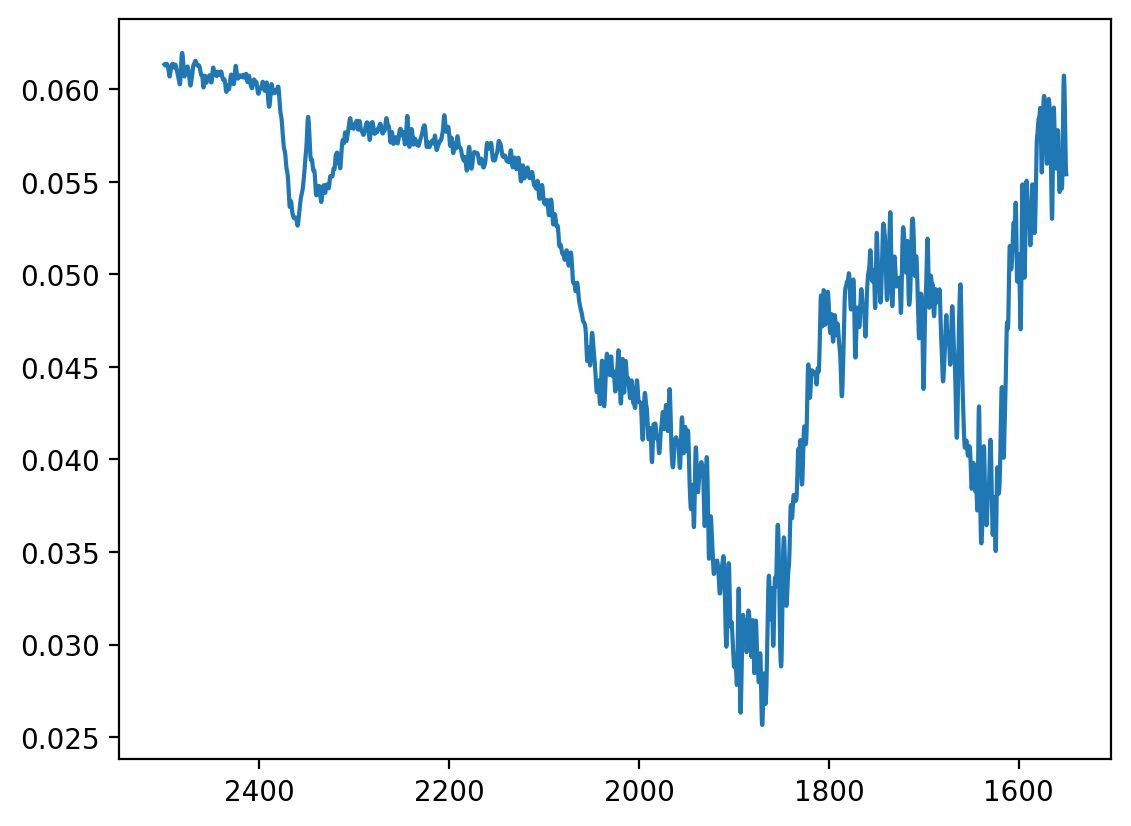

In [7]:
#Use this cell to preview your data to decide how you want to fit it and what regions you want to look at
df_source = df_spec_2D
wn1 = 2500 # Start in wn
wn2= 1550 # End in wn

slice_point =20 # Enter the index of the spectra you want to look at here (get a timepoint that lets you see what you want)
t_df = get_time_p(slice_point,df_source)
print(t_df)
#Finds the location of that wavenumber in the index
wn1_df = df_source.loc[:,t_df].iloc[(np.absolute(df_source.index-wn1)).argsort()[:1]].index[0]
wn2_df = df_source.loc[:,t_df].iloc[(np.absolute(df_source.index-wn2)).argsort()[:1]].index[0]

plt.plot(df_source.loc[wn1_df:wn2_df,t_df].index.to_numpy(),df_source.loc[wn1_df:wn2_df,t_df].values.squeeze())
plt.gca().invert_xaxis() 

In [68]:
#Fitting
print(file_name)
slice_time =2.5
slice_point = 0
for slice_point in range(len(df_phase_set.columns)):
    slice_time = df_phase_set.columns[slice_point]
    #df_test = ((df_averaged2D.loc[:,slice_time]+df_averaged2D.loc[:,200+slice_time]+df_averaged2D.loc[:,400+slice_time]+df_averaged2D.loc[:,600+slice_time-40]+df_averaged2D.loc[:,800+slice_time])/5)
    # Apply FFT to the signal
    
    df_source = df_phase_set
    adj_col = np.array([abs(float(x-(slice_time))) for x in df_source.columns.to_numpy()])
    #print(df_source.columns.to_numpy())
    t_df = df_source.iloc[:, adj_col.argsort()[:1]].columns
    #print(df_source.iloc[:, adj_col.argsort()[:1]].columns)
    wn1 = 2200 # Start in wn
    wn2= 2020 # End in wn
    #Finds the location of that wavenumber in the index
    wn1_df = df_source.loc[:,t_df].iloc[(np.absolute(df_source.index-wn1)).argsort()[:1]].index[0]
    wn2_df = df_source.loc[:,t_df].iloc[(np.absolute(df_source.index-wn2)).argsort()[:1]].index[0]
    
    ydat = df_source.loc[wn1_df:wn2_df,t_df].values.squeeze()
    xdat = df_source.loc[wn1_df:wn2_df,t_df].index.to_numpy()
    
    
    
    
    
    
    
    plt.close()
    model = QuadraticModel(prefix='bkg_')
    params = model.make_params(a=-5.5513e-07 , b=0.000108225 , c=-0.04 )
    
    
   # rough_peak_positions = [2094.1,2113.1,2127.5,2105.0]

    #rough_fwhm = [15.7,14.9,17.5,36.4]
    rough_peak_positions = [2106]
    rough_fwhm =[34.7]
    rough_ampl = (0.001,0.001,0.001,-0.001,0.001,0.001,-0.001) 
    rough_frac = (0.986,0.35,0.6,0.051,0.986,0.35,0.6,0.051)
    
    for i, cen in enumerate(rough_peak_positions): 
        peak, pars = add_fancy_peak('lz%d_' % (i+1), cen, rough_ampl[i],rough_fwhm[i],rough_frac[i]) 
        model = model + peak 
        params.update(pars) 
    init = model.eval(params, x=xdat) 
    result = model.fit(ydat, params, x=xdat) 
    comps = result.eval_components()
    
    fit_tracker[slice_time] = {}
    fit_tracker[slice_time]["result"] = result.fit_report(show_correl = False)
    fit_tracker[slice_time]["names"] = []
    fit_tracker[slice_time]["locations"] = []
    fit_tracker[slice_time]["FWHM"] = []
    fit_tracker[slice_time]["areas"] = []
    fit_tracker[slice_time]["areas_error"] = []
    data_tracker[slice_time] = {}
    data_tracker[slice_time]["xdat"] = xdat 
    data_tracker[slice_time]["ydat"] = ydat
    data_tracker[slice_time]["best fit"] = result.best_fit
    for name, comp in comps.items():
        data_tracker[slice_time][name] = comp
        if name != "bkg_":
            fit_tracker[slice_time]["names"].append(name)
            fit_tracker[slice_time]["locations"].append(result.best_values[name+"center"])
            fit_tracker[slice_time]["FWHM"].append(result.params[name+"fwhm"].value)
            fit_tracker[slice_time]["areas"].append(result.params[name+"amplitude"].value)
            fit_tracker[slice_time]["areas_error"].append(result.params[name+"amplitude"].stderr)
    print(fit_tracker[slice_time]["areas_error"])
    

FTIR_241218_CuAl2O3_CO_Oxidze_100ppm_550600_113mW_200s5s_split
[9.439956379695018e-05]
[9.128774070887334e-05]
[9.069859582869032e-05]
[9.229860257356384e-05]
[9.620404108579026e-05]
[9.77883211359796e-05]
[9.698930930537701e-05]
[9.800517161060948e-05]
[9.924063139454779e-05]
[9.851931582325784e-05]
[0.00010290236445316086]
[0.00010292983796870437]
[0.00010110449308859514]
[0.00010562872485189769]
[0.00010745675796458791]
[0.00010654398098145941]
[0.00010201982406133164]
[9.409922313081058e-05]
[9.433972310630085e-05]
[9.570843464931407e-05]
[9.439956434953595e-05]
[9.12877409240302e-05]
[9.069859627277949e-05]
[9.229860240079793e-05]
[9.620404098205075e-05]
[9.778832053776841e-05]
[9.698930919650198e-05]
[9.800517147661316e-05]
[9.92406304779338e-05]
[9.851931564226223e-05]
[0.00010290236546594974]
[0.00010292983949859045]
[0.00010110449265274222]
[0.00010562876892417359]
[0.0001074567585403187]
[0.00010654398115683324]
[0.00010201982347392235]
[9.409922380601827e-05]
[9.433972255946

20
102.5
[[Model]]
    (Model(parabolic, prefix='bkg_') + Model(pvoigt, prefix='lz1_'))
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 11
    # data points      = 747
    # variables        = 4
    chi-square         = 2.1320e-07
    reduced chi-square = 2.8695e-10
    Akaike info crit   = -16408.8876
    Bayesian info crit = -16390.4234
    R-squared          = 0.69758338
[[Variables]]
    bkg_a:         -9.8790e-10 +/- 3.3890e-10 (34.30%) (init = 0)
    bkg_b:          4.2601e-06 +/- 1.4297e-06 (33.56%) (init = 0.000108225)
    bkg_c:         -0.00500053 +/- 0.00150670 (30.13%) (init = -0.04)
    lz1_amplitude:  0.00274126 +/- 9.4400e-05 (3.44%) (init = 0.001)
    lz1_center:     2106 (fixed)
    lz1_sigma:      17.35 (fixed)
    lz1_fraction:   0 (fixed)
    lz1_fwhm:       34.7000000 +/- 0.00000000 (0.00%) == '2.0000000*lz1_sigma'
    lz1_height:     7.4214e-05 +/- 2.5557e-06 (3.44%) == '(((1-lz1_fraction)*lz1_amplitude)/max(1e-15, (lz1_sigma*sqrt(pi/l

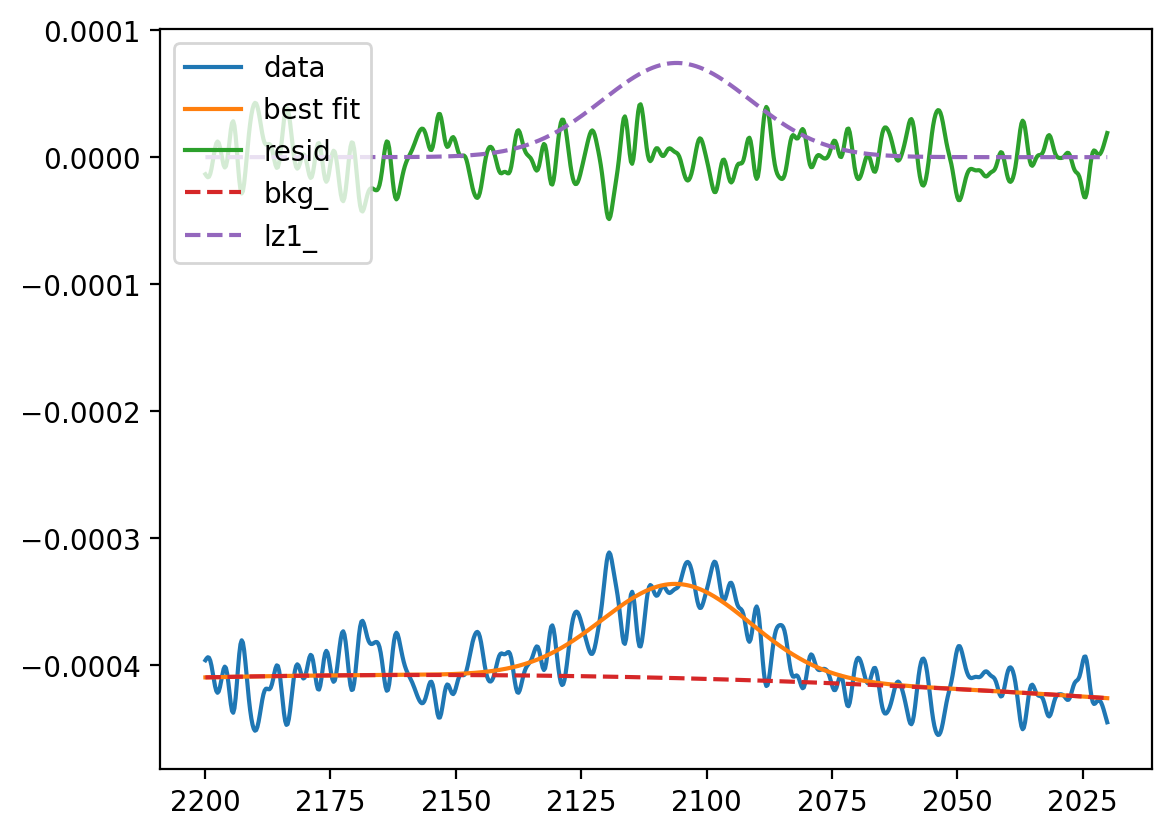

In [76]:
plt.close()
slice_point =20
print(slice_point)


slice_time = df_phase_set.columns[slice_point]
print(slice_time)
df_source = df_phase_set
adj_col = np.array([abs(float(x-(slice_time))) for x in df_source.columns.to_numpy()])
#print(df_source.columns.to_numpy())
t_df = df_source.iloc[:, adj_col.argsort()[:1]].columns

wn1 = 2200 # Start in wn
wn2= 2020 # End in wn
#Finds the location of that wavenumber in the index
wn1_df = df_source.loc[:,t_df].iloc[(np.absolute(df_source.index-wn1)).argsort()[:1]].index[0]
#wn2_df = df_source.loc[:,t_df].iloc[(df_source.loc[:,t_df]-wn2).squeeze().abs().argsort()[:1]].index[0]
wn2_df = df_source.loc[:,t_df].iloc[(np.absolute(df_source.index-wn2)).argsort()[:1]].index[0]

ydat = df_source.loc[wn1_df:wn2_df,t_df].values.squeeze()
#ydat = pd.Series(ydat)
xdat = df_source.loc[wn1_df:wn2_df,t_df].index.to_numpy()


model = QuadraticModel(prefix='bkg_')
params = model.make_params(m=-5.5513e-07 , b=0.000108225, c=-0.04 )
#rough_peak_positions = [2094.1,2113.1,2127.5,2107.0]
rough_peak_positions = [2106]
rough_fwhm =[34.7]
#rough_fwhm = [15.7,14.9,17.5,25.4]

#rough_peak_positions = [2094.4,2112.2,2125.6,2102.8]

#rough_fwhm = [15.6,14.8,15.6,43.5] 

#rough_peak_positions = (2155,2125.7,2040.6,2009,1981.1,1886.4,1723.5,1657.2)
#rough_fwhm = (55,27.3,20.7,30.2,29.5,57.4,64.1,71.1) 
rough_ampl = (0.001,0.001,0.001,0.001,0.001,0.001,0.001,0.001) 
rough_frac = (0.986,0.35,0.6,0.051,0.986,0.35,0.6,0.051,0.051)

#rough_peak_positions = (2099.9,2114.7,2125.0, 2087.0,2009,1981.1,2034.6)
#rough_fwhm = (15.1,12.4,14.1,16.1,30.2,29.5,24.7) 

for i, cen in enumerate(rough_peak_positions): 
    peak, pars = add_fancy_peak('lz%d_' % (i+1), cen, rough_ampl[i],rough_fwhm[i],rough_frac[i]) 
    model = model + peak 
    params.update(pars) 
init = model.eval(params, x=xdat) 
result = model.fit(ydat, params, x=xdat) 
comps = result.eval_components()

fit_tracker[slice_time] = {}
fit_tracker[slice_time]["result"] = result.fit_report(show_correl = False)
fit_tracker[slice_time]["names"] = []
fit_tracker[slice_time]["locations"] = []
fit_tracker[slice_time]["FWHM"] = []
fit_tracker[slice_time]["areas"] = []
fit_tracker[slice_time]["areas_error"] = []
data_tracker[slice_time] = {}
data_tracker[slice_time]["xdat"] = xdat 
data_tracker[slice_time]["ydat"] = ydat
data_tracker[slice_time]["best fit"] = result.best_fit
for name, comp in comps.items():
    data_tracker[slice_time][name] = comp
    if name != "bkg_":
        fit_tracker[slice_time]["names"].append(name)
        fit_tracker[slice_time]["locations"].append(result.best_values[name+"center"])
        fit_tracker[slice_time]["FWHM"].append(result.params[name+"fwhm"].value)
        fit_tracker[slice_time]["areas"].append(result.params[name+"amplitude"].value)
        fit_tracker[slice_time]["areas_error"].append(result.params[name+"amplitude"].stderr)
print(result.fit_report(show_correl = False))

plt.plot(xdat, ydat, label='data') 
plt.plot(xdat, result.best_fit, label='best fit')
plt.plot(xdat, result.best_fit-ydat, label='resid')
for name, comp in comps.items(): 
    plt.plot(xdat, comp, '--', label=name)
plt.legend(loc='upper left')
plt.gca().invert_xaxis() 
plt.show()

#Saving the fits
data_fit_tracker = fit_tracker.copy()
data_data_tracker = data_tracker.copy()
times = []
frames = []
reports = ''
datas = []
for time, d in enumerate(data_fit_tracker):
    times.append(d)
    if "result" in data_fit_tracker[d]:
        reports=(reports+str(d) +"\n"+ data_fit_tracker[d]["result"]+"\n\n")
    data_fit_tracker[d].pop("result", None)
    frames.append(pd.DataFrame.from_dict(data_fit_tracker[d], orient='index'))
for time, d in enumerate(data_data_tracker):
    datas.append(pd.DataFrame.from_dict(data_data_tracker[d], orient='index'))
df_fit=pd.concat(frames, keys=times)
print(df_fit)
df_datum=pd.concat(datas, keys=times)
df_fit.to_csv(file_name + "Best_Fit2020_2200V4.csv",',')
df_datum.to_csv(file_name + "Best_Fit_Values2020_2200V4.csv",',')
f = open(file_name + "Best_Fit2020_2200V4.txt", "w")
f.write(reports)
f.close() 

In [70]:
#Saving the fits 
data_fit_tracker = fit_tracker.copy() 
data_data_tracker = data_tracker.copy() 
times = [] 
frames = [] 
reports = '' 
datas = [] 
for time, d in enumerate(data_fit_tracker):
    times.append(d) 
    if "result" in data_fit_tracker[d]: 
        reports=(reports+str(d) +"\n"+ data_fit_tracker[d]["result"]+"\n\n") 
        data_fit_tracker[d].pop("result", None) 
        
    frames.append(pd.DataFrame.from_dict(data_fit_tracker[d], orient='index')) 
for time, d in enumerate(data_data_tracker): 
    datas.append(pd.DataFrame.from_dict(data_data_tracker[d], orient='index'))
    df_fit=pd.concat(frames, keys=times) 
print(df_fit) 
print(file_name)
df_datum=pd.concat(datas, keys=times) 
df_fit.to_csv(file_name + "Best_Fit2020_2200V4.csv",',') 
df_datum.to_csv(file_name + "Best_Fit_Values2020_2200V4.csv",',') 
f = open(file_name + "Best_Fit2020_2200V4.txt", "w") 
f.write(reports) 
f.close()

                          0
102.5 names            lz1_
      locations        2106
      FWHM             34.7
      areas        0.002741
      areas_error  0.000094
...                     ...
197.5 names            lz1_
      locations        2106
      FWHM             34.7
      areas       -0.002511
      areas_error  0.000096

[200 rows x 1 columns]
FTIR_241218_CuAl2O3_CO_Oxidze_100ppm_550600_113mW_200s5s_split


C:\Users\jdnor\AppData\Local\Temp\ipykernel_44296\4108674263.py:21: FutureWarning: Starting with pandas version 3.0 all arguments of to_csv except for the argument 'path_or_buf' will be keyword-only.
  df_fit.to_csv(file_name + "Best_Fit2020_2200V4.csv",',')
C:\Users\jdnor\AppData\Local\Temp\ipykernel_44296\4108674263.py:22: FutureWarning: Starting with pandas version 3.0 all arguments of to_csv except for the argument 'path_or_buf' will be keyword-only.
  df_datum.to_csv(file_name + "Best_Fit_Values2020_2200V4.csv",',')


[-0.0002, -0.0001, 0.0, 0.0001, 0.0002]


<Figure size 640x480 with 0 Axes>

<Figure size 1066.67x800 with 0 Axes>

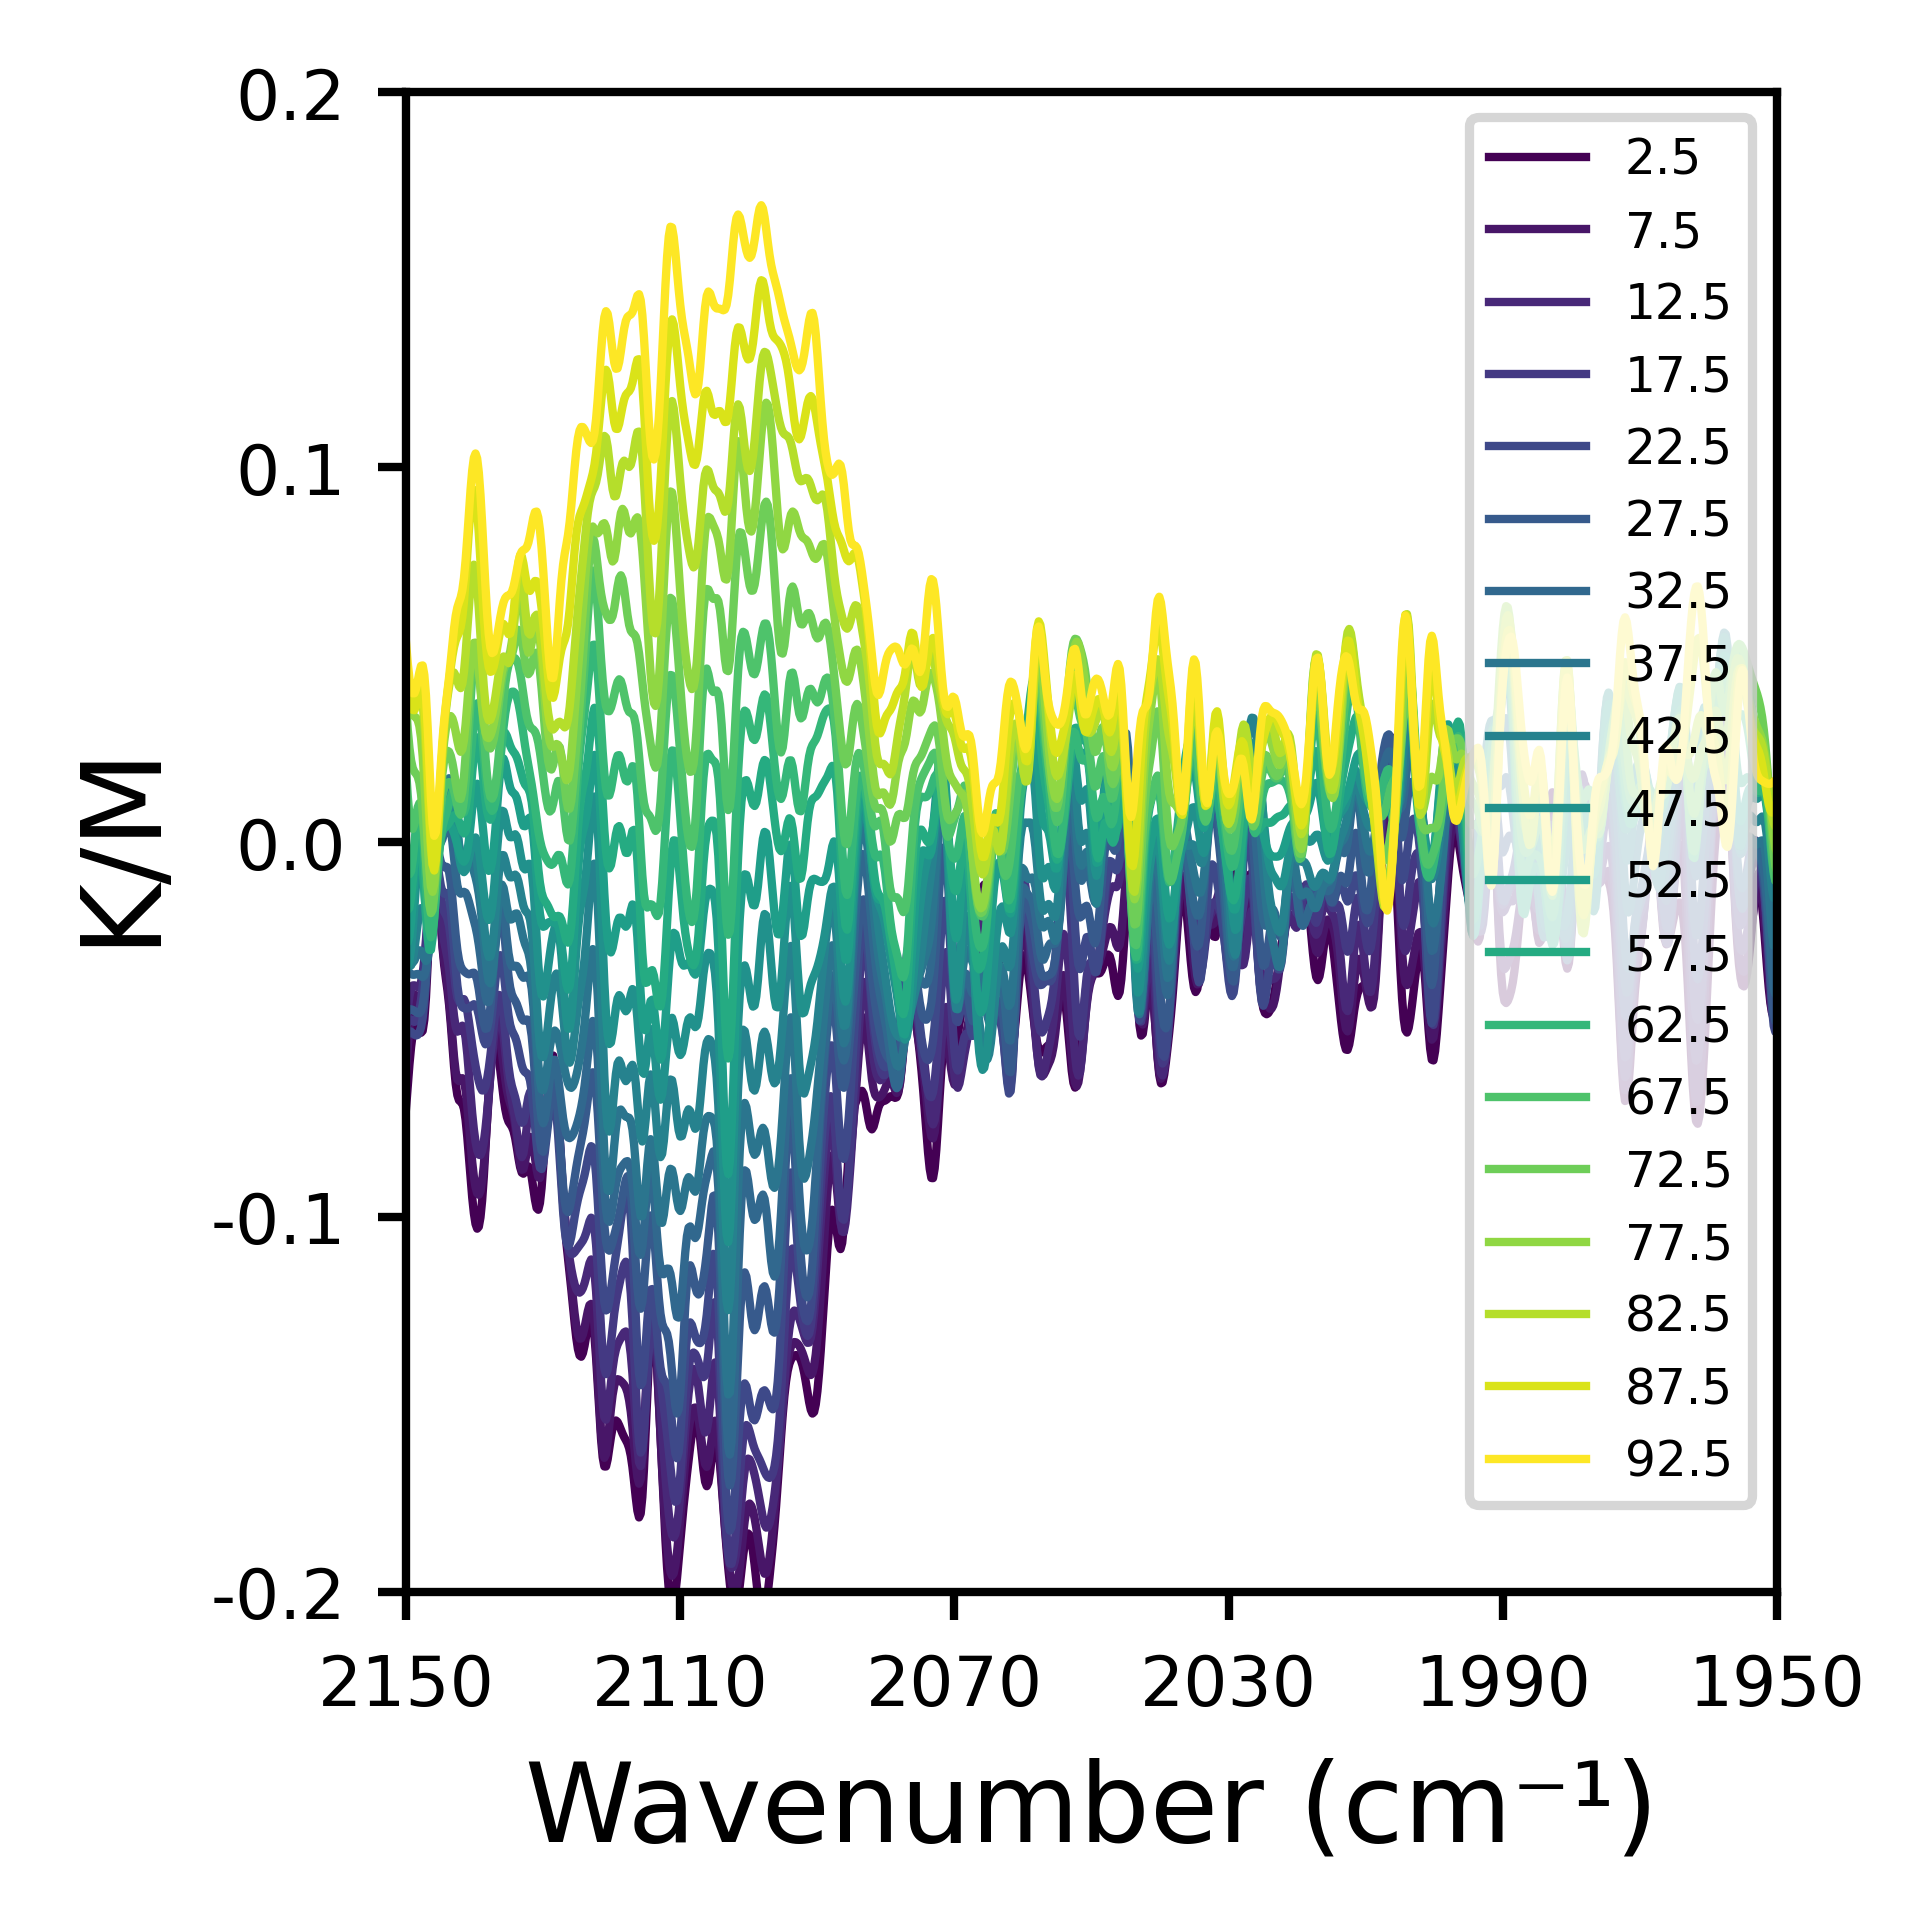

In [37]:
#Plotting a trace of a number of phase slices
# Fontsize scales everything in the figure. Change this to change the size of all the text and lines
#This allows you to dynamically adjust the figure to the size you want it with the text adjusting as well
# Controls the text size of all labels so it remains proportional. Change this with your figure size to get good alignment
font_size = 1.5
# Color cycle for the series of traces, see pyplot docs for different options
cmap = mpl.colormaps['viridis'] 
plt.set_cmap(cmap) 
#Font settings to make it processable in illustrator as a pdf, don't change these
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['font.family'] = 'DejaVu Sans' #This is a helvetica similar font that is easy to change in illustrator
#Font importing is difficult in python, if you get it feel free to change this

#Put the name you want for your figure here, it will be saved as "Fig_'Name'" with both a jpg for quick use and an eps for detailed edits.
fig_name = 'FTIR_241107_CuAl2O3_Reduce_500ppmCO_550600nm_119mW_200s_2nd5s_split_display_V3'
#X axis limits
wn1 = 2150 # Start in wn
wn2= 1900 # End in wn
#Finds the location of that wavenumber in the index
wn1_df = df_phase_set.iloc[np.abs((df_phase_set.index.to_numpy()-wn1)).argsort()[:1]].index[0]
wn2_df = df_phase_set.iloc[np.abs((df_phase_set.index.to_numpy()-wn2)).argsort()[:1]].index[0]  


plt.figure(linewidth = 0.6*font_size,dpi=250*(1/font_size)) #sets appropriate linewidth and pixel count based on font size
#figsize defines the figure in (width, height) in inches, change here to change the size of the figure
#Remember you can adjust your font_size to match your new figure size 
fig,ax = plt.subplots(dpi=250*(1/font_size),figsize=(3, 3),linewidth = 0.6*font_size)
ax.set_prop_cycle(plt.cycler("color", (cmap(k) for k in np.linspace(0, 1, 19))))
#ax.plot(xdat, ydat, label='data',linewidth = 0.6*font_size)
#ax.plot(xdat, result.best_fit, label='best fit',linewidth = 0.6*font_size)
#ax.plot(xdat, ydat-result.best_fit, label='resid',linewidth = 0.6*font_size)
kernel_size = 5
kernel = np.ones(kernel_size) / kernel_size
for x,time in enumerate(df_phase_set.columns[0:19]):

    adj = df_phase_set.loc[:,time].mean()
        
    ax.plot(df_phase_set.index, df_phase_set.loc[:,time].to_numpy()-adj , '-', label=time,linewidth = 0.6*font_size)
#np.convolve(, kernel, mode='same')
#ax.axvline(x=2125.0, color = "magenta")
#ax.axvline(x=2099.9, color = "black")
#ax.axvline(x=2114.7, color = "slategray")
#ax.axvline(x=2034.6, color = "firebrick")
#ax.axvline(x=2009, color = "chocolate")
#ax.axvline(x=1981.1, color = "slateblue")
#ax.axvline(x=2105.9, color = "red")

#Generation of the figure, change the figsize for the application you want (poster paper etc)

#drift = table_for_plot.set_index('Wavenumber').plot(figsize=(3, 2), linewidth = 0.6*font_size, ax = ax,cmap = cmap)
#adjusts the dpi based on size
size = fig.get_size_inches()
if size[0]<=size[1]:
    rgh_size = size[0]
else :  
    rgh_size = size[1]
fig.dpi=1000/rgh_size

#makes it standard for plotting wavenumbers on the reverse axis
plt.gca().invert_xaxis()


#Following settings can be changed based on what you want your chart to look like
# Axis labels
ax.set_xlabel("Wavenumber (cm" + get_super("-1") + ")", fontsize = 8*font_size,)
ax.set_ylabel("K/M", fontsize = 8*font_size)#,labelpad=5)

#Set axis line widths
for axis in ['bottom','left']:
    ax.spines[axis].set_linewidth(0.6*font_size)
    ax.spines[axis].set_position(("axes", 0))
for axis in ['top','right']:
    #True to false if you want the top right axes to be invisible
    ax.spines[axis].set_visible(True)
    ax.spines[axis].set_linewidth(0.6*font_size)


# And adjust length and tkickness of tick marks
ax.tick_params(width = 0.6*font_size, length = 2*font_size)
ax.tick_params(axis='both', which='minor', labelsize=8)
plt.xticks(fontsize=5*font_size)
plt.yticks(fontsize=5*font_size)
ax.yaxis.set_ticks_position('left')
ax.xaxis.set_ticks_position('bottom')


#Adjusting range and tick frequency of x axis
xhigh = 2150 #High Range
xlow = 1950#Low Range
xpoints = 6 # How many points you want on your axis
xdigits = 0 # Percision of tick points, will round to how many digits you enter here

xlabels = [round(num, xdigits) for num in np.linspace(xlow, xhigh, xpoints)]
if xdigits <= 0:
    xlabels = [int(num) for num in xlabels]
ax.set_xticks(xlabels)
ax.set_xticklabels(xlabels)
ax.set_xlim(xhigh, xlow)

#Adjusting range and tick frequency of y axis
yhigh = 0.0002 #High Range
ylow = -0.0002 #Low Range
ypoints = 5 #How many points you want on your axis
ydigits = 4 # Percision of tick points, will round to how many digits you enter here

ylabels = [round(num,ydigits) for num in np.linspace(ylow, yhigh, ypoints)]
if ydigits <= 0:
    ylabels = [int(num) for num in ylabels]
print (ylabels)
ax.set_yticks(ylabels)
ydistort = []
for i,y in enumerate(ylabels):
    ydistort.append(y*1000)
ax.set_yticklabels(ydistort)
ax.set_ylim(ylow, yhigh)

#This code can be used to remove tick labels entirely
#ax.set_yticks([])
#ax.set_yticklabels([])
#ax.axes.get_yaxis().set_visible(False)

#Adjust the location and title  of the legend
#Options are 'best', 'upper left', 'upper right', 'lower left', 'lower right', 'upper center', 'lower center', 'center left', 'center right', 'center' 
#For more fine tuning edit it in illustrator
ax.legend(fontsize = 3.5*font_size, loc = "upper right", title_fontsize =4*font_size)
plt.tight_layout()


#Saving and plotting of figure

#plt.savefig(Path.cwd() / "Plot_{}.pdf".format(fig_name), format='pdf')
plt.show()